In [1]:
from scipy.ndimage import correlate
from skimage import color, io, measure, img_as_ubyte, img_as_float
from skimage.measure import profile_line
from skimage.transform import rescale, resize
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import erosion, dilation, opening, closing
from skimage.morphology import disk 

In [2]:
# From https://scikit-image.org/docs/stable/auto_examples/applications/plot_morphology.html
def plot_comparison(original, filtered, filter_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True, sharey=True)
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title("original")
    ax1.axis("off")
    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis("off")
    io.show()

In [3]:
def threshold_image(img: np.array, thresh: float):
    """
    Obtains a threshold image

    Args:
        img (np.array): input image
        threshold (float): gamma coefficient

    Return:
        threshold_img (np.array): newly mapped image
    """
    return img > thresh

In [4]:
folder_path = "data/"
im_org = rgb2gray(io.imread(folder_path + "lego_5.png"))

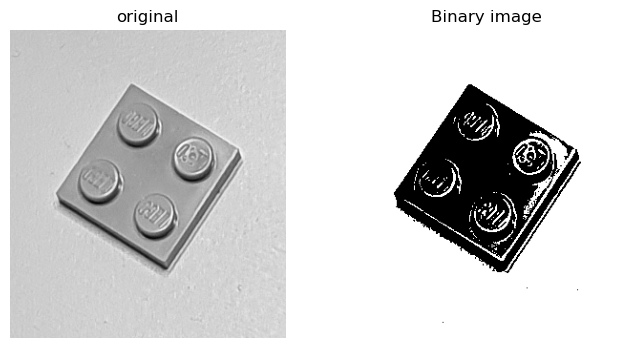

In [6]:
from skimage.filters import threshold_otsu

threshold = threshold_otsu(im_org)
bin_img = threshold_image(im_org, threshold)
plot_comparison(im_org, bin_img, "Binary image")

## Create structuring element aka footprint

In [9]:
footprint = disk(1)
# Check the size and shape of the structuring element
print(footprint)

[[0 1 0]
 [1 1 1]
 [0 1 0]]


The morphological operation erosion can remove small objects, separate objects and make objects smaller. Try it on the binary lego image:

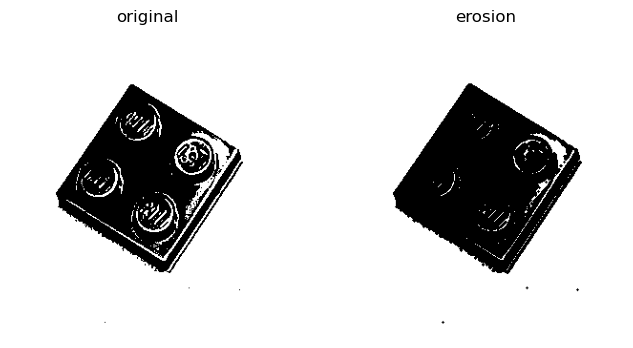

In [10]:
eroded = erosion(bin_img, footprint)
plot_comparison(bin_img, eroded, "erosion")

The morphological operation dilation makes objects larger, closes holes and connects objects. Try it on the binary lego image:


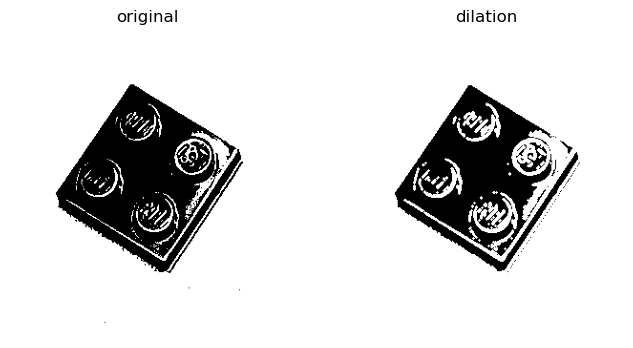

In [11]:
dilated = dilation(bin_img, footprint)
plot_comparison(bin_img, dilated, "dilation")

The morphological operation opening removes small objects without changing the size of the remaining objects. Try it on the binary lego image:

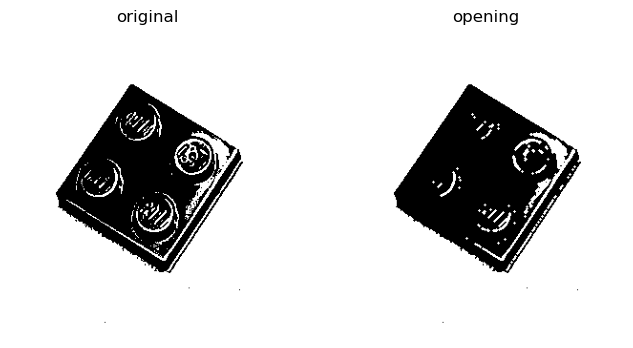

In [12]:
opened = opening(bin_img, footprint)
plot_comparison(bin_img, opened, "opening")

The morphological operation closing closes holes in objects without changing the size of the remaining objects. Try it on the binary lego image:



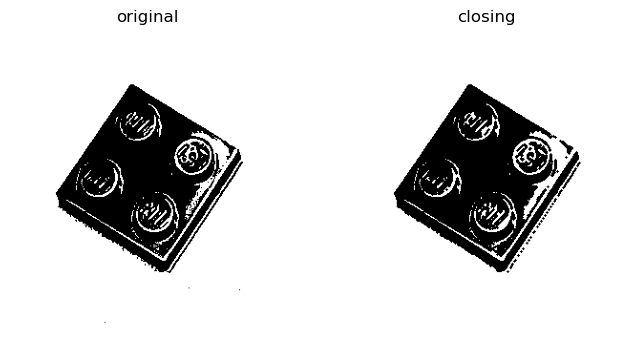

In [13]:
closed = closing(bin_img, footprint)
plot_comparison(bin_img, closed, "closing")

In [14]:
def compute_outline(bin_img):
    """
    Computes the outline of a binary image
    """
    footprint = disk(1)
    dilated = dilation(bin_img, footprint)
    outline = np.logical_xor(dilated, bin_img)
    return outline

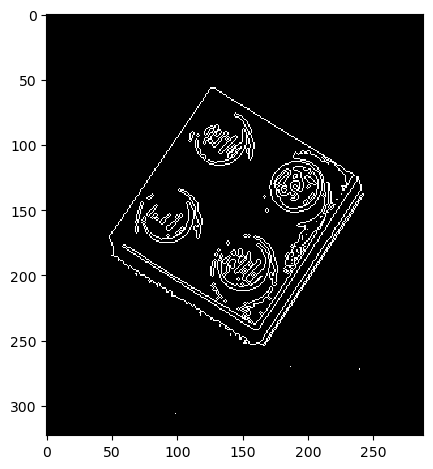

In [17]:
io.imshow(compute_outline(bin_img))

* Do an opening with a disk of size 1 on the binary lego image.
* Do a closing with a disk of size 15 on the result of the opening.
* Compute the outline and visualize it.

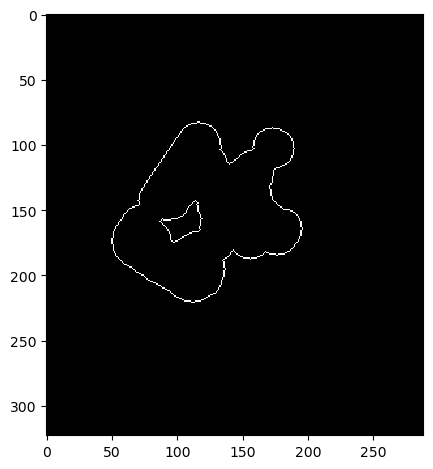

In [20]:
io.imshow(compute_outline(closing(opening(bin_img, disk(1)), disk(15))))

## Morphology on multiple objects

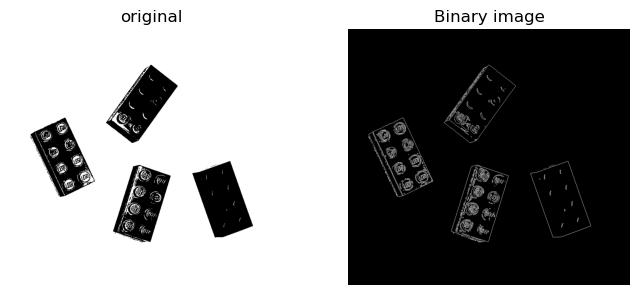

In [23]:
lego_7 = rgb2gray(io.imread(folder_path + "lego_7.png"))
threshold = threshold_otsu(lego_7)
bin_img = threshold_image(lego_7, threshold)
plot_comparison(bin_img, compute_outline(bin_img), "Binary image")

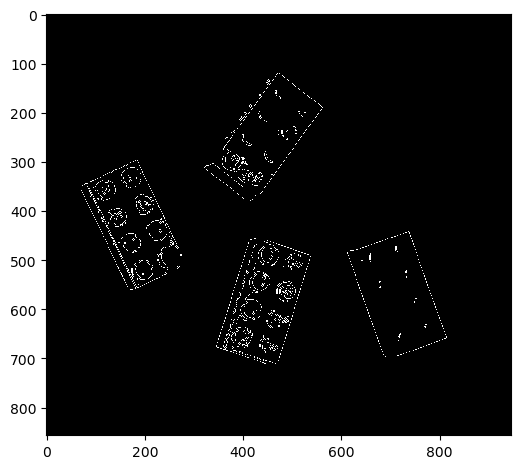

In [38]:
test_img = compute_outline(closing(bin_img, disk(2)))
io.imshow(test_img)

## Morphology on multiple connected objects

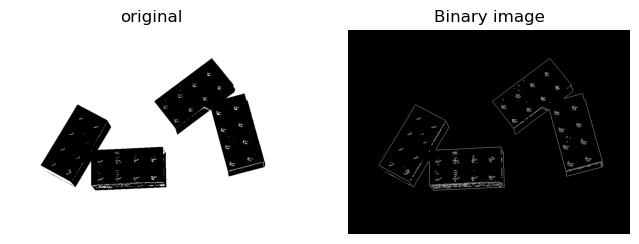

In [39]:
lego_9 = rgb2gray(io.imread(folder_path + "lego_9.png"))
threshold = threshold_otsu(lego_9)
bin_img = threshold_image(lego_9, threshold)
plot_comparison(bin_img, compute_outline(bin_img), "Binary image")

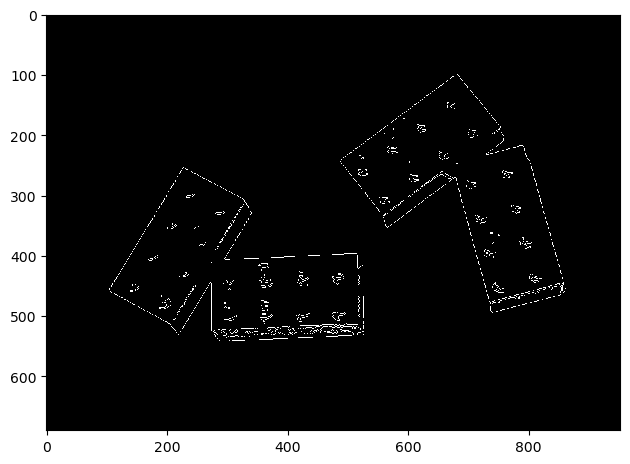

In [40]:
test_img = compute_outline(closing(bin_img, disk(2)))
io.imshow(test_img)

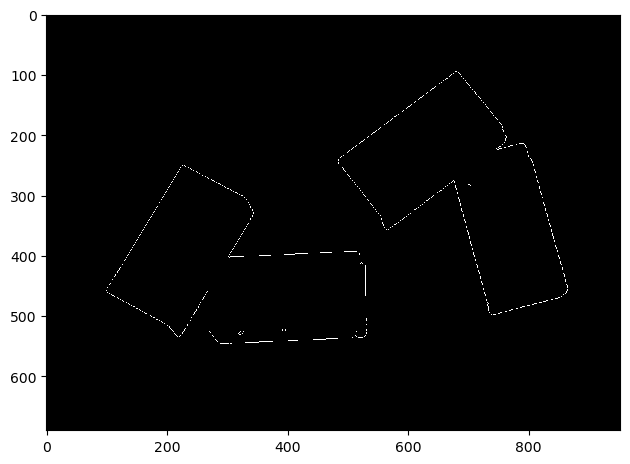

In [50]:
sep_img = compute_outline(erosion(closing(bin_img, disk(2)), disk(4)))
io.imshow(sep_img)

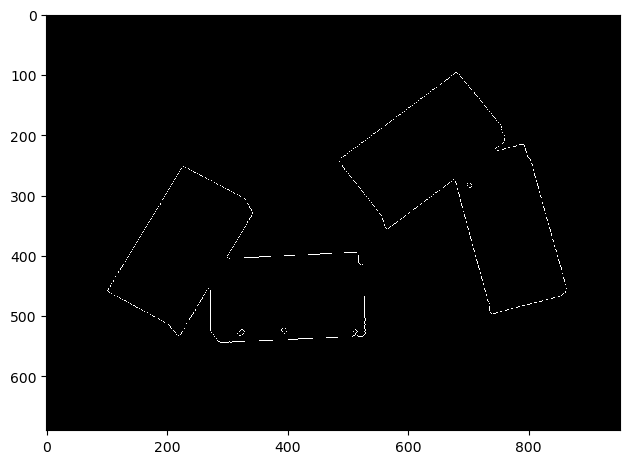

In [52]:
dilate_img = compute_outline(dilation(erosion(closing(bin_img, disk(2)), disk(4)), disk(2)))
io.imshow(dilate_img)